# checking annotation format (csv vs txt)

In [3]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

dataset_root = r"..\dataset"
csv_path = os.path.join(dataset_root, "annotations.csv")
txt_path = os.path.join(dataset_root, "annotation.txt")
shelf_dir = os.path.join(dataset_root, "ShelfImages")


In [4]:
raw_csv_df = pd.read_csv(csv_path)
raw_csv_df.head(10)

,C1_P01_N1_S2_1.JPG,1008,1552,1260,1928,0
0,C1_P01_N1_S2_1.JPG,1028,928,1280,1304,0
1,C1_P01_N1_S2_1.JPG,24,872,268,1264,0
2,C1_P01_N1_S2_1.JPG,280,1568,532,1944,0
3,C1_P01_N1_S2_1.JPG,292,872,544,1248,0
4,C1_P01_N1_S2_1.JPG,40,1560,292,1936,0
5,C1_P01_N1_S2_1.JPG,528,900,780,1276,0
6,C1_P01_N1_S2_1.JPG,536,1556,788,1932,0
7,C1_P01_N1_S2_1.JPG,768,1564,1020,1940,0
8,C1_P01_N1_S2_1.JPG,780,908,1032,1284,0
9,C1_P01_N1_S2_2.JPG,1372,1556,1872,2304,0


In [5]:
#there is no header for feature so using this approach
raw_csv_df = pd.read_csv(csv_path, header=None)
raw_csv_df.head(10)

# now checking if row 0 is an actual header or just data
# if the non filename columns in row 0 can be converted to int, its data not a header
first_row = raw_csv_df.iloc[0]
has_header = False
for val in first_row[1:]:
    try:
        int(val)
    except:
        has_header = True
        break

print("has_header:", has_header)

if has_header:
    csv_df = raw_csv_df.iloc[1:].reset_index(drop=True)
else:
    csv_df = raw_csv_df.copy()

csv_df.columns = ["filename", "val1", "val2", "val3", "val4", "val5"]
csv_df[["val1","val2","val3","val4","val5"]] = csv_df[["val1","val2","val3","val4","val5"]].astype(int)
csv_df.head(10)

has_header: False


,filename,val1,val2,val3,val4,val5
0,C1_P01_N1_S2_1.JPG,1008,1552,1260,1928,0
1,C1_P01_N1_S2_1.JPG,1028,928,1280,1304,0
2,C1_P01_N1_S2_1.JPG,24,872,268,1264,0
3,C1_P01_N1_S2_1.JPG,280,1568,532,1944,0
4,C1_P01_N1_S2_1.JPG,292,872,544,1248,0
5,C1_P01_N1_S2_1.JPG,40,1560,292,1936,0
6,C1_P01_N1_S2_1.JPG,528,900,780,1276,0
7,C1_P01_N1_S2_1.JPG,536,1556,788,1932,0
8,C1_P01_N1_S2_1.JPG,768,1564,1020,1940,0
9,C1_P01_N1_S2_1.JPG,780,908,1032,1284,0


In [6]:
with open(txt_path, "r") as f:
    raw_lines = [l.strip() for l in f if l.strip()]

print("lines in txt:", len(raw_lines))
print(raw_lines[0])


lines in txt: 354
C1_P01_N1_S2_1.JPG 10 1008 1552 252 376 0 1028 928 252 376 0 24 872 244 392 0 280 1568 252 376 0 292 872 252 376 0 40 1560 252 376 0 528 900 252 376 0 536 1556 252 376 0 768 1564 252 376 0 780 908 252 376 0


In [7]:
txt_records = []
for line in raw_lines:
    parts = line.split()
    fname = parts[0]
    n = int(parts[1])
    vals = parts[2:]
    for i in range(n):
        v1, v2, v3, v4, v5 = vals[i*5:(i+1)*5]
        txt_records.append([fname, int(v1), int(v2), int(v3), int(v4), int(v5)])

txt_df = pd.DataFrame(txt_records, columns=["filename", "val1", "val2", "val3", "val4", "val5"])
print(txt_df.shape)
txt_df.head(10)


(13184, 6)


,filename,val1,val2,val3,val4,val5
0,C1_P01_N1_S2_1.JPG,1008,1552,252,376,0
1,C1_P01_N1_S2_1.JPG,1028,928,252,376,0
2,C1_P01_N1_S2_1.JPG,24,872,244,392,0
3,C1_P01_N1_S2_1.JPG,280,1568,252,376,0
4,C1_P01_N1_S2_1.JPG,292,872,252,376,0
5,C1_P01_N1_S2_1.JPG,40,1560,252,376,0
6,C1_P01_N1_S2_1.JPG,528,900,252,376,0
7,C1_P01_N1_S2_1.JPG,536,1556,252,376,0
8,C1_P01_N1_S2_1.JPG,768,1564,252,376,0
9,C1_P01_N1_S2_1.JPG,780,908,252,376,0


now comparing csv and txt to see if they actually hold the same data. doing a direct compare first, val1/val2 should be x,y in both so those should always line up. if val3/val4 don't match directly, csv might be storing x2,y2 (bottom right corner) instead of w,h, so trying that conversion

In [8]:
def compare(txt_df, csv_df):
    checked = 0
    mismatched = 0
    missing = 0
    for fname, grp in txt_df.groupby("filename"):
        txt_boxes = set(map(tuple, grp[["val1","val2","val3","val4","val5"]].values))
        csv_grp = csv_df[csv_df["filename"] == fname]
        if len(csv_grp) == 0:
            missing += 1
            continue
        csv_boxes = set(map(tuple, csv_grp[["val1","val2","val3","val4","val5"]].values))
        checked += 1
        if txt_boxes != csv_boxes:
            mismatched += 1
    return checked, mismatched, missing

checked, mismatched, missing = compare(txt_df, csv_df)
print(f"direct compare -> checked: {checked}, mismatched: {mismatched}, missing in csv: {missing}")


direct compare -> checked: 354, mismatched: 354, missing in csv: 0


In [9]:
# if direct compare failed, try assuming csv val3/val4 are x2,y2 instead of w,h and convert to w,h before comparing again
if mismatched > 0:
    csv_df_converted = csv_df.copy()
    csv_df_converted["val3"] = csv_df_converted["val3"] - csv_df_converted["val1"]  # x2 -> w
    csv_df_converted["val4"] = csv_df_converted["val4"] - csv_df_converted["val2"]  # y2 -> h

    checked2, mismatched2, missing2 = compare(txt_df, csv_df_converted)
    print(f"after treating csv val3/val4 as x2,y2 -> checked: {checked2}, mismatched: {mismatched2}, missing: {missing2}")

    if mismatched2 < mismatched:
        print("csv is storing x1,y1,x2,y2,b, not x1,y1,w,h,b. txt and csv hold the same data just in different box format")
    else:
        print("still not matching, csv and txt might genuinely be different / from different sources")
else:
    print("csv and txt already match directly, both hold same data")


after treating csv val3/val4 as x2,y2 -> checked: 354, mismatched: 0, missing: 0
csv is storing x1,y1,x2,y2,b, not x1,y1,w,h,b. txt and csv hold the same data just in different box format


csv checks out against txt, so going ahead with txt from here since we already have it parsed. now the real question - is it x,y,w,h,b or x,y,h,w,b, no way to tell just by looking at the numbers

In [10]:
# hypothesis A -> val1=x, val2=y, val3=w, val4=h
txt_df["A_x1"] = txt_df["val1"]
txt_df["A_y1"] = txt_df["val2"]
txt_df["A_x2"] = txt_df["val1"] + txt_df["val3"]
txt_df["A_y2"] = txt_df["val2"] + txt_df["val4"]

# hypothesis B -> val1=x, val2=y, val3=h, val4=w (w and h swapped)
txt_df["B_x1"] = txt_df["val1"]
txt_df["B_y1"] = txt_df["val2"]
txt_df["B_x2"] = txt_df["val1"] + txt_df["val4"]
txt_df["B_y2"] = txt_df["val2"] + txt_df["val3"]


In [11]:
# walking the whole dataset_root once and mapping filename -> full path
# this way it doesn't matter if images are directly in ShelfImages, or in a train/test subfolder
file_lookup = {}
for root, dirs, files in os.walk(dataset_root):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            file_lookup[f.lower()] = os.path.join(root, f)

print("total image files found under dataset_root:", len(file_lookup))
print("sample paths:", list(file_lookup.values())[:3])

img_dims = {}
not_found = []
for fname in txt_df["filename"].unique():
    path = file_lookup.get(fname.lower())
    if path is None:
        not_found.append(fname)
        continue
    img = cv2.imread(path)
    if img is None:
        not_found.append(fname)
        continue
    h, w = img.shape[:2]
    img_dims[fname] = (w, h)

print("matched:", len(img_dims), " not found:", len(not_found))
if not_found:
    print("a few missing filenames:", not_found[:5])

txt_df["img_w"] = txt_df["filename"].map(lambda f: img_dims.get(f, (np.nan, np.nan))[0])
txt_df["img_h"] = txt_df["filename"].map(lambda f: img_dims.get(f, (np.nan, np.nan))[1])

matched = txt_df.dropna(subset=["img_w", "img_h"])
print("images matched with actual files:", matched["filename"].nunique())

total image files found under dataset_root: 354
sample paths: ['..\\dataset\\ShelfImages\\test\\C1_P02_N1_S5_1.JPG', '..\\dataset\\ShelfImages\\test\\C1_P02_N2_S2_1.JPG', '..\\dataset\\ShelfImages\\test\\C1_P02_N2_S3_1.JPG']
matched: 354  not found: 0
images matched with actual files: 354


In [12]:
# a box that goes outside the image is obviously the wrong interpretation
def out_of_bounds_pct(df, x2_col, y2_col):
    bad = (df[x2_col] > df["img_w"]) | (df[y2_col] > df["img_h"])
    return bad.mean() * 100

pct_A = out_of_bounds_pct(matched, "A_x2", "A_y2")
pct_B = out_of_bounds_pct(matched, "B_x2", "B_y2")

print("hypothesis A (x,y,w,h,b) out of bounds:", round(pct_A, 2), "%")
print("hypothesis B (x,y,h,w,b) out of bounds:", round(pct_B, 2), "%")


hypothesis A (x,y,w,h,b) out of bounds: 0.09 %
hypothesis B (x,y,h,w,b) out of bounds: 2.53 %


also drawing it on an actual image, easier to just look and confirm

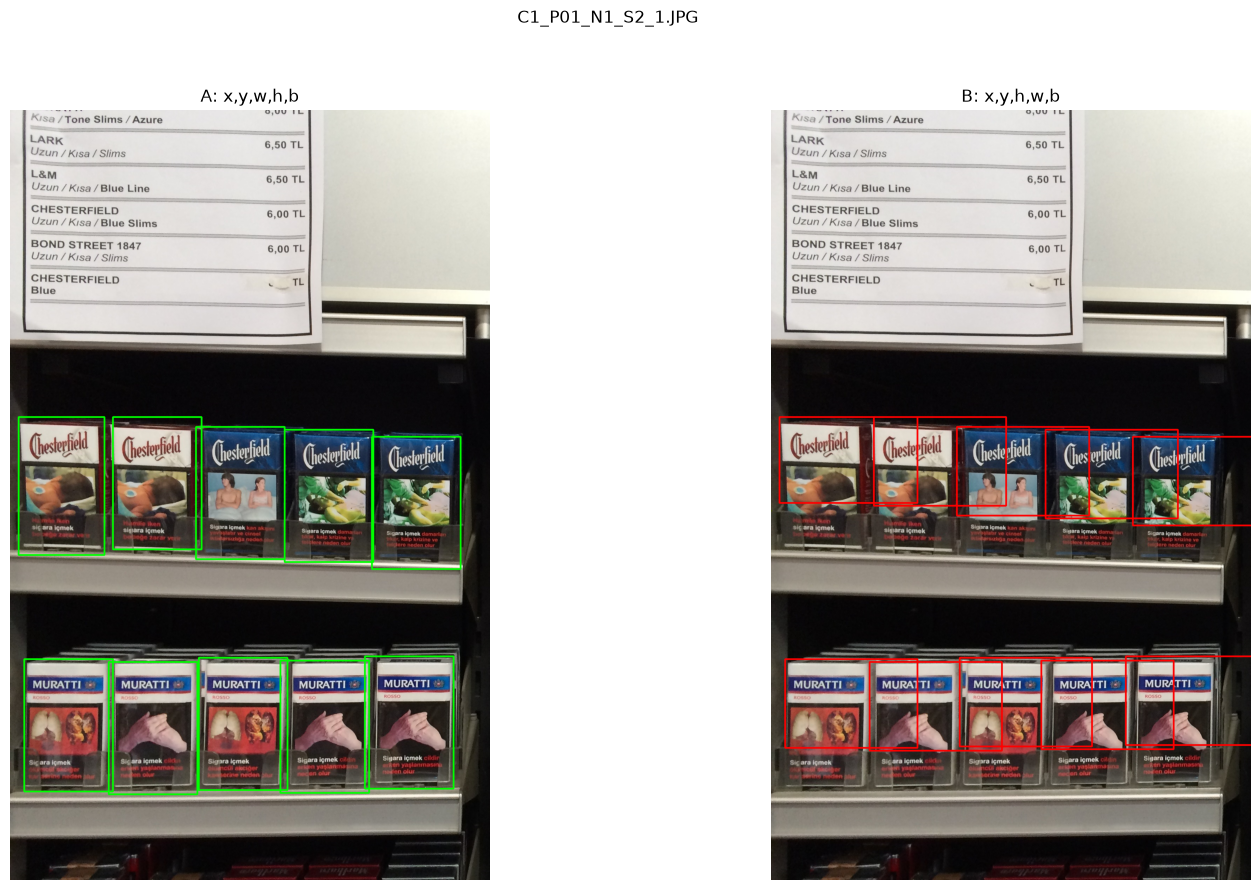

In [13]:
sample_fname = matched["filename"].iloc[0]
sample = matched[matched["filename"] == sample_fname]

img = cv2.cvtColor(cv2.imread(file_lookup[sample_fname.lower()]), cv2.COLOR_BGR2RGB)
img_A = img.copy()
img_B = img.copy()

for _, row in sample.iterrows():
    cv2.rectangle(img_A, (int(row.A_x1), int(row.A_y1)), (int(row.A_x2), int(row.A_y2)), (0,255,0), 4)
    cv2.rectangle(img_B, (int(row.B_x1), int(row.B_y1)), (int(row.B_x2), int(row.B_y2)), (255,0,0), 4)

fig, ax = plt.subplots(1, 2, figsize=(18,10))
ax[0].imshow(img_A); ax[0].set_title("A: x,y,w,h,b"); ax[0].axis("off")
ax[1].imshow(img_B); ax[1].set_title("B: x,y,h,w,b"); ax[1].axis("off")
plt.suptitle(sample_fname)
plt.show()


In [14]:
# whichever has less out of bounds boxes + boxes actually look right in the image is the real format
# as i we can clearly see
if pct_A < pct_B:
    print("going with x,y,w,h,b")
else:
    print("going with x,y,h,w,b")


going with x,y,w,h,b
